# Bước 3: Apriori Modeling for Association Rules

Notebook này sử dụng ma trận `basket_bool` (được chuẩn bị ở bước 02) để:

- Khai thác **tập mục phổ biến** (frequent itemsets) bằng thuật toán **Apriori**
- Sinh **luật kết hợp** (association rules) với các chỉ số: `support`, `confidence`, `lift`
- Lọc luật theo các ngưỡng do người dùng cấu hình
- Trực quan hoá một số nhóm luật tiêu biểu phục vụ storytelling & phân tích kinh doanh
- Lưu kết quả luật đã lọc ra file `.csv` để sử dụng trong báo cáo, dashboard hoặc các bước phân tích tiếp theo

Notebook được thiết kế theo kiểu *parameterized* để dễ dàng tích hợp với **papermill**, cho phép chạy tự động với các ngưỡng support/confidence khác nhau mà không cần sửa code.


In [1]:
# PARAMETERS (for papermill)

# Đường dẫn tới basket_bool được tạo từ Notebook 02
BASKET_BOOL_PATH = "data/processed/basket_bool.parquet"

# Đường dẫn lưu file luật kết hợp sau khi lọc
RULES_OUTPUT_PATH = "data/processed/rules_apriori_filtered.csv"

# Tham số cho bước khai thác tập mục phổ biến (frequent itemsets)
MIN_SUPPORT = 0.01     # ngưỡng support tối thiểu
MAX_LEN = 3            # độ dài tối đa của itemset (số sản phẩm trong 1 tập)

# Tham số cho bước sinh luật
METRIC = "lift"        # chỉ số dùng để generate rules: 'support' / 'confidence' / 'lift'
MIN_THRESHOLD = 1.0    # ngưỡng tối thiểu cho METRIC

# Tham số lọc luật sau khi generate
FILTER_MIN_SUPPORT = 0.01
FILTER_MIN_CONF = 0.3
FILTER_MIN_LIFT = 1.2
FILTER_MAX_ANTECEDENTS = 2
FILTER_MAX_CONSEQUENTS = 1

# Số lượng luật top để vẽ biểu đồ
TOP_N_RULES = 20

# Bật/tắt các biểu đồ matplotlib
PLOT_TOP_LIFT = True
PLOT_TOP_CONF = True
PLOT_SCATTER = True
PLOT_NETWORK = True

# Bật/tắt biểu đồ HTML tương tác (Plotly)
PLOT_PLOTLY_SCATTER = True


## Set up

In [12]:
import sys
import os

# 1. Xác định vị trí hiện tại
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "..", ".."))

# 3. Trỏ vào thư mục src
src_path = os.path.join(project_root, "src")

# 4. Thêm vào hệ thống để Python tìm thấy
if src_path not in sys.path:
    sys.path.append(src_path)

print("Đường dẫn chuẩn (đã sửa):", src_path)

# Giờ mới Import
try:
    from apriori_library import AssociationRulesMiner, DataVisualizer
    print("Tìm thấy thư viện")
except ImportError as e:
    print(" Lỗi:", e)


Đường dẫn chuẩn (đã sửa): d:\3\Data_Mining\Buoi2\shopping_cart_analysis\src
Tìm thấy thư viện


## Thiết lập style vẽ biểu đồ 

In [13]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


In [14]:
# Khởi tạo DataVisualizer với style đã cấu hình
visualizer = DataVisualizer()

## Tải basket_bool

In [17]:
# Đọc ma trận basket_bool từ bước 2
BASKET_BOOL_PATH = "../processed/basket_bool.parquet"

if os.path.exists(BASKET_BOOL_PATH):
        basket_bool = pd.read_parquet(BASKET_BOOL_PATH)
        print("=== Thông tin basket_bool ===")
        print(f"- Số hoá đơn (rows): {basket_bool.shape[0]:,}")
        print(f"- Số sản phẩm (columns): {basket_bool.shape[1]:,}")
        print(f"- Tỷ lệ ô = 1 (có mua): {basket_bool.values.mean():.4f}")

        basket_bool.head()
else:
    print(f"File không tồn tại: {BASKET_BOOL_PATH}")

=== Thông tin basket_bool ===
- Số hoá đơn (rows): 16,646
- Số sản phẩm (columns): 3,844
- Tỷ lệ ô = 1 (có mua): 0.0054


In [18]:
import sys
import os

# 1. Xác định vị trí hiện tại
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "..", ".."))

# 3. Trỏ vào thư mục src
src_path = os.path.join(project_root, "src")

# 4. Thêm vào hệ thống để Python tìm thấy
if src_path not in sys.path:
    sys.path.append(src_path)

print("Đường dẫn chuẩn (đã sửa):", src_path)

# Giờ mới Import
try:
    from apriori_library import AssociationRulesMiner, DataVisualizer
    print("Tìm thấy thư viện")
except ImportError as e:
    print(" Lỗi:", e)


Đường dẫn chuẩn (đã sửa): d:\3\Data_Mining\Buoi2\shopping_cart_analysis\src
Tìm thấy thư viện


## Khai thác tập phổ biến bằng thuật toán Apriori

In [19]:
# Khởi tạo Apriori miner
miner = AssociationRulesMiner(basket_bool=basket_bool)

start_time = time.time()
frequent_itemsets_ap = miner.mine_frequent_itemsets(
    min_support=MIN_SUPPORT,
    max_len=MAX_LEN,
    use_colnames=True,
)
elapsed_time = time.time() - start_time

print("=== Kết quả khai thác tập mục phổ biến (Apriori) ===")
print(f"- Thời gian chạy: {elapsed_time:.2f} giây")
print(f"- Số tập mục phổ biến thu được: {len(frequent_itemsets_ap):,}")

frequent_itemsets_ap.head(10)


=== Kết quả khai thác tập mục phổ biến (Apriori) ===
- Thời gian chạy: 31.30 giây
- Số tập mục phổ biến thu được: 968


,support,itemsets
582,0.113180,(WHITE HANGING HEART T-LIGHT HOLDER)
250,0.086928,(JUMBO BAG RED RETROSPOT)
413,0.084705,(REGENCY CAKESTAND 3 TIER)
38,0.078097,(ASSORTED COLOUR BIRD ORNAMENT)
340,0.077496,(PARTY BUNTING)
285,0.067283,(LUNCH BAG RED RETROSPOT)
466,0.060495,(SET OF 3 CAKE TINS PANTRY DESIGN )
277,0.059834,(LUNCH BAG BLACK SKULL.)
334,0.056770,(PAPER CHAIN KIT 50'S CHRISTMAS )
308,0.056350,(NATURAL SLATE HEART CHALKBOARD )


c:\Users\buih7\anaconda3\envs\shopping_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\Users\buih7\anaconda3\envs\shopping_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
c:\Users\buih7\anaconda3\envs\shopping_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


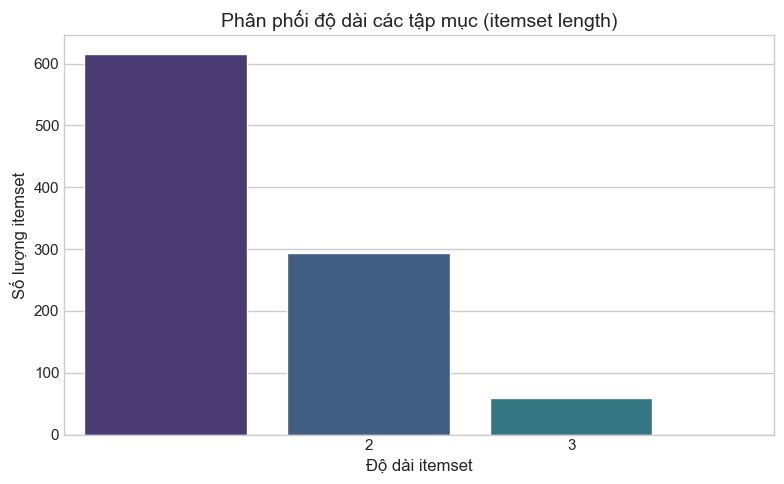

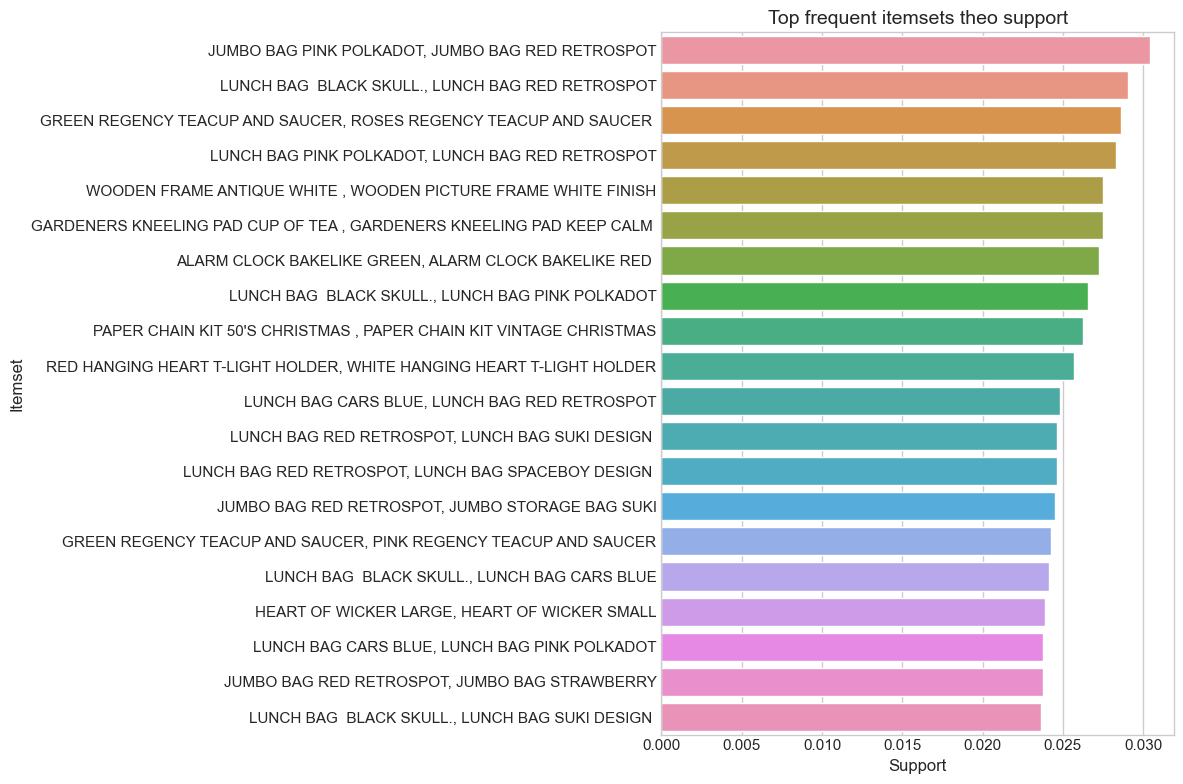

In [20]:
# Trực quan hoá frequent itemsets trước khi sinh luật
if frequent_itemsets_ap is not None and not frequent_itemsets_ap.empty:
    # Phân phối độ dài các tập mục (1-itemset, 2-itemset, 3-itemset, ...)
    visualizer.plot_itemset_length_distribution(
        frequent_itemsets=frequent_itemsets_ap
    )

    # Top các tập mục phổ biến nhất theo support (ưu tiên itemset có từ 2 sản phẩm trở lên)
    visualizer.plot_top_frequent_itemsets(
        frequent_itemsets=frequent_itemsets_ap,
        top_n=20,
        min_len=2
    )
else:
    print("Không có frequent itemsets để trực quan hoá.")


## Sinh luật kết hợp từ tập mục phổ biến

In [21]:
rules_ap = miner.generate_rules(
    metric=METRIC,
    min_threshold=MIN_THRESHOLD,
)

# Thêm cột dạng chuỗi dễ đọc
rules_ap = miner.add_readable_rule_str()

print("=== Một vài luật kết hợp đầu tiên (chưa lọc) ===")
cols_preview = [
    "antecedents_str",
    "consequents_str",
    "support",
    "confidence",
    "lift",
]
rules_ap[cols_preview].head(10)


=== Một vài luật kết hợp đầu tiên (chưa lọc) ===


,antecedents_str,consequents_str,support,confidence,lift
909,HERB MARKER THYME,HERB MARKER ROSEMARY,0.010153,0.944134,86.829038
908,HERB MARKER ROSEMARY,HERB MARKER THYME,0.010153,0.933702,86.829038
586,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE ROSES,0.011534,0.845815,52.930211
587,REGENCY TEA PLATE ROSES,REGENCY TEA PLATE GREEN,0.011534,0.721805,52.930211
901,POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE BEDROOM,0.010153,0.808612,51.769856
900,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE LIVINGROOM,0.010153,0.650000,51.769856
844,SET OF 3 WOODEN STOCKING DECORATION,SET OF 3 WOODEN TREE DECORATIONS,0.010333,0.690763,50.211536
845,SET OF 3 WOODEN TREE DECORATIONS,SET OF 3 WOODEN STOCKING DECORATION,0.010333,0.751092,50.211536
759,POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE KITCHEN,0.010693,0.851675,49.225611
758,POPPY'S PLAYHOUSE KITCHEN,POPPY'S PLAYHOUSE LIVINGROOM,0.010693,0.618056,49.225611


## Lọc các luật theo ngưỡng support/ confidence / lift

In [22]:
rules_filtered_ap = miner.filter_rules(
    min_support=FILTER_MIN_SUPPORT,
    min_confidence=FILTER_MIN_CONF,
    min_lift=FILTER_MIN_LIFT,
    max_len_antecedents=FILTER_MAX_ANTECEDENTS,
    max_len_consequents=FILTER_MAX_CONSEQUENTS,
)

print("=== Thống kê sau khi lọc luật ===")
print(f"- Tổng số luật ban đầu: {rules_ap.shape[0]:,}")
print(f"- Số luật sau khi lọc: {rules_filtered_ap.shape[0]:,}")

rules_filtered_ap[cols_preview].head(10)


=== Thống kê sau khi lọc luật ===
- Tổng số luật ban đầu: 942
- Số luật sau khi lọc: 568


,antecedents_str,consequents_str,support,confidence,lift
0,HERB MARKER THYME,HERB MARKER ROSEMARY,0.010153,0.944134,86.829038
1,HERB MARKER ROSEMARY,HERB MARKER THYME,0.010153,0.933702,86.829038
2,REGENCY TEA PLATE GREEN,REGENCY TEA PLATE ROSES,0.011534,0.845815,52.930211
3,REGENCY TEA PLATE ROSES,REGENCY TEA PLATE GREEN,0.011534,0.721805,52.930211
4,POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE BEDROOM,0.010153,0.808612,51.769856
5,POPPY'S PLAYHOUSE BEDROOM,POPPY'S PLAYHOUSE LIVINGROOM,0.010153,0.650000,51.769856
6,SET OF 3 WOODEN STOCKING DECORATION,SET OF 3 WOODEN TREE DECORATIONS,0.010333,0.690763,50.211536
7,SET OF 3 WOODEN TREE DECORATIONS,SET OF 3 WOODEN STOCKING DECORATION,0.010333,0.751092,50.211536
8,POPPY'S PLAYHOUSE LIVINGROOM,POPPY'S PLAYHOUSE KITCHEN,0.010693,0.851675,49.225611
9,POPPY'S PLAYHOUSE KITCHEN,POPPY'S PLAYHOUSE LIVINGROOM,0.010693,0.618056,49.225611


## Trực quan top các luật theo Lift

In [23]:
visualizer = DataVisualizer()


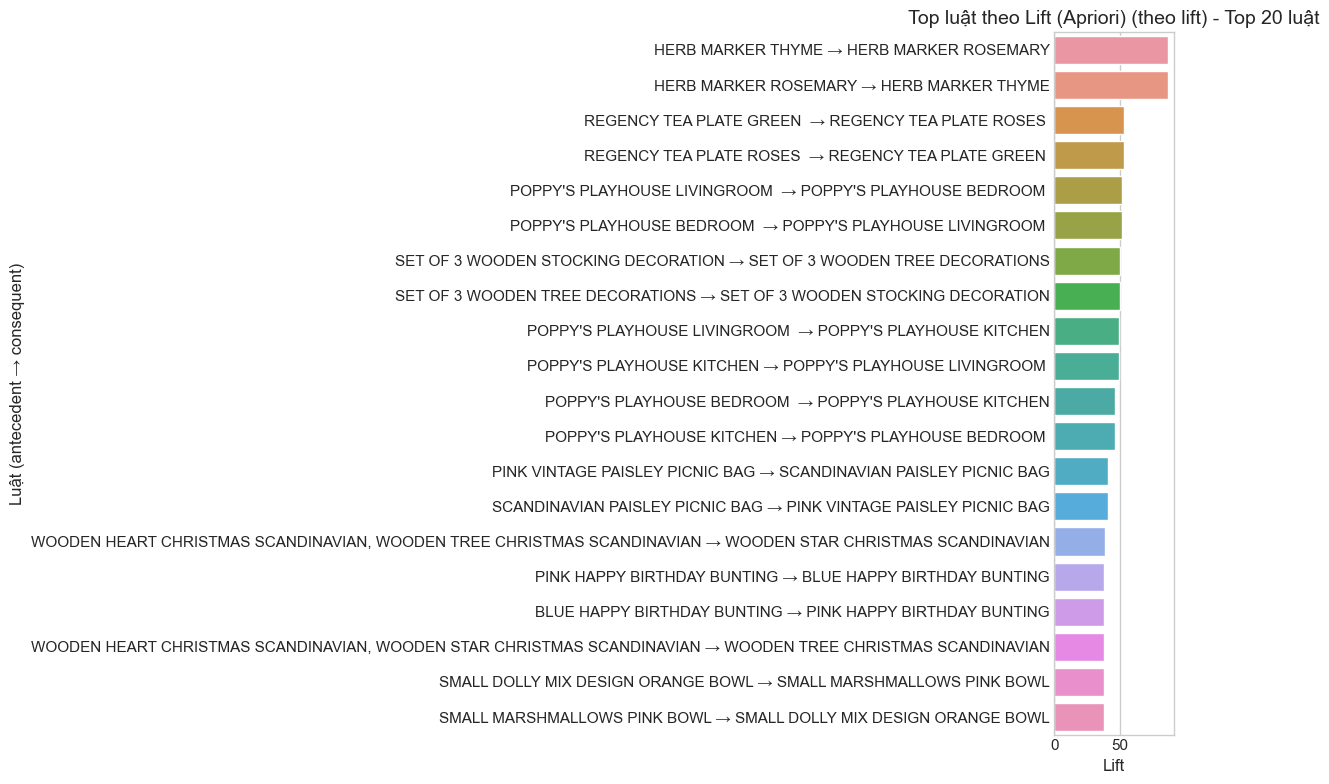

In [24]:
if PLOT_TOP_LIFT and not rules_filtered_ap.empty:
    visualizer.plot_top_rules_lift(
        rules_df=rules_filtered_ap,
        top_n=TOP_N_RULES,
    )
else:
    if rules_filtered_ap.empty:
        print("Không có luật nào sau khi lọc để vẽ top lift.")
    else:
        print("PLOT_TOP_LIFT = False, bỏ qua biểu đồ top lift.")


## Trực quan top luật theo confidence

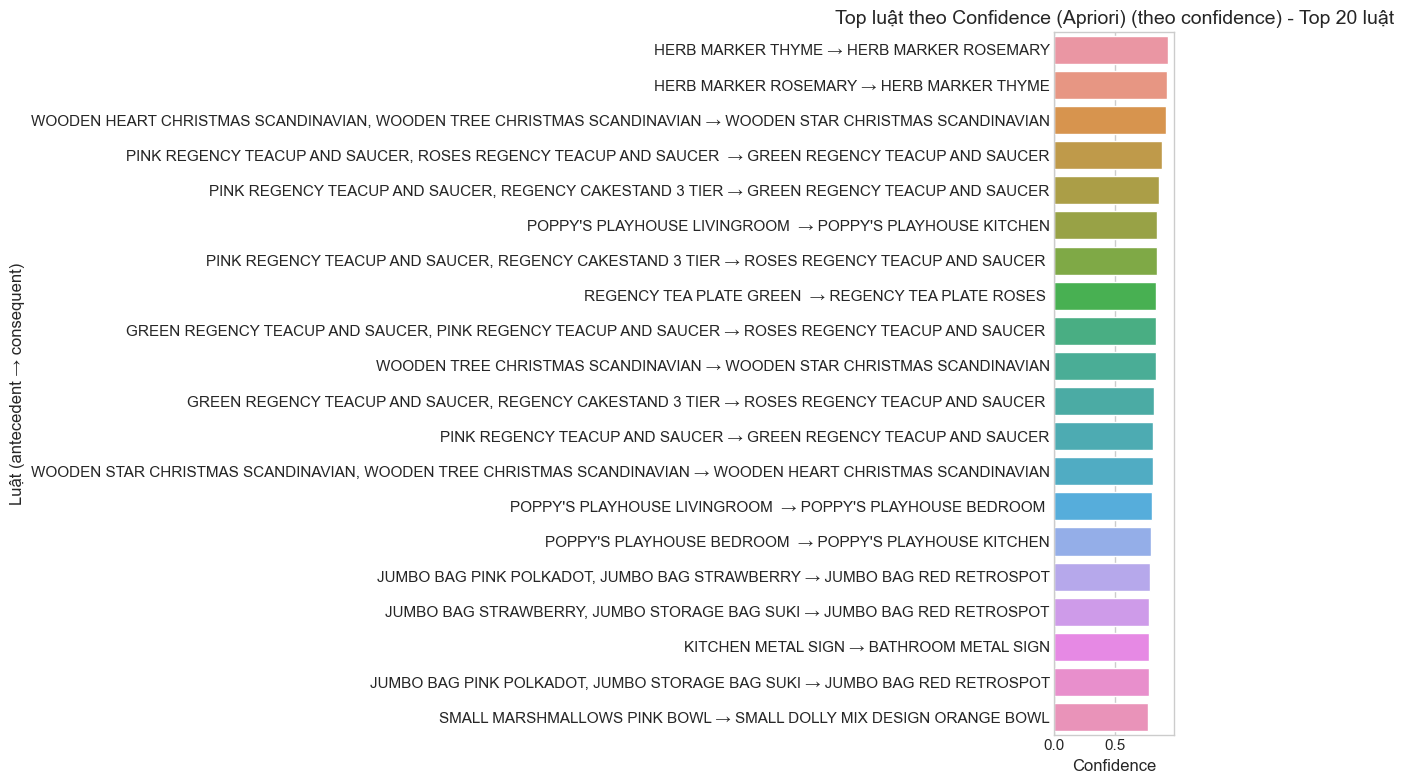

In [25]:
if PLOT_TOP_CONF and not rules_filtered_ap.empty:
    visualizer.plot_top_rules_confidence(
        rules_df=rules_filtered_ap,
        top_n=TOP_N_RULES,
    )
else:
    if rules_filtered_ap.empty:
        print("Không có luật nào sau khi lọc để vẽ top confidence.")
    else:
        print("PLOT_TOP_CONF = False, bỏ qua biểu đồ top confidence.")


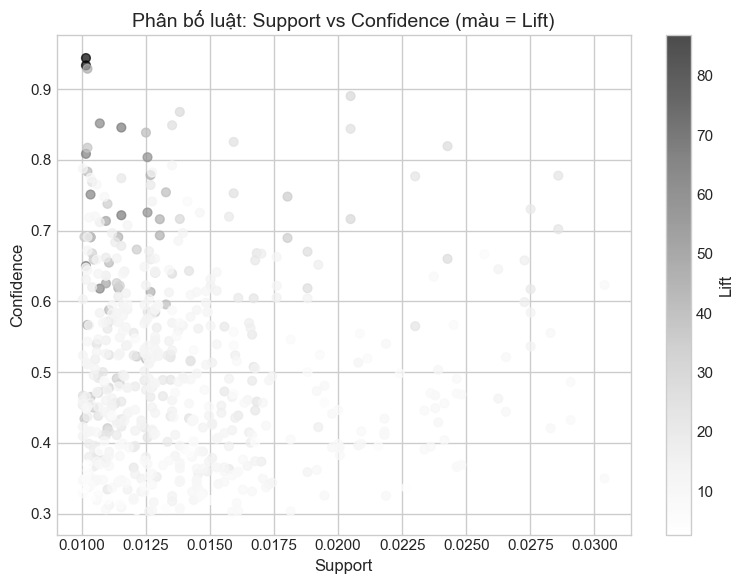

In [26]:
# Trực quan hoá quan hệ support vs confidence
if PLOT_SCATTER and not rules_filtered_ap.empty:
    visualizer.plot_rules_support_confidence_scatter(
        rules_df=rules_filtered_ap,
    )
else:
    if rules_filtered_ap.empty:
        print("Không có luật nào sau khi lọc để vẽ scatter.")
    else:
        print("PLOT_SCATTER = False, bỏ qua biểu đồ scatter.")


In [27]:
## Tạo biểu đồ bằng HTML (Plotly)
if PLOT_PLOTLY_SCATTER and not rules_filtered_ap.empty:
    visualizer.plot_rules_support_confidence_scatter_interactive(
        rules_df=rules_filtered_ap,
    )
else:
    if rules_filtered_ap.empty:
        print("Không có luật nào sau khi lọc để vẽ scatter Plotly.")
    else:
        print("PLOT_PLOTLY_SCATTER = False, bỏ qua biểu đồ Plotly.")


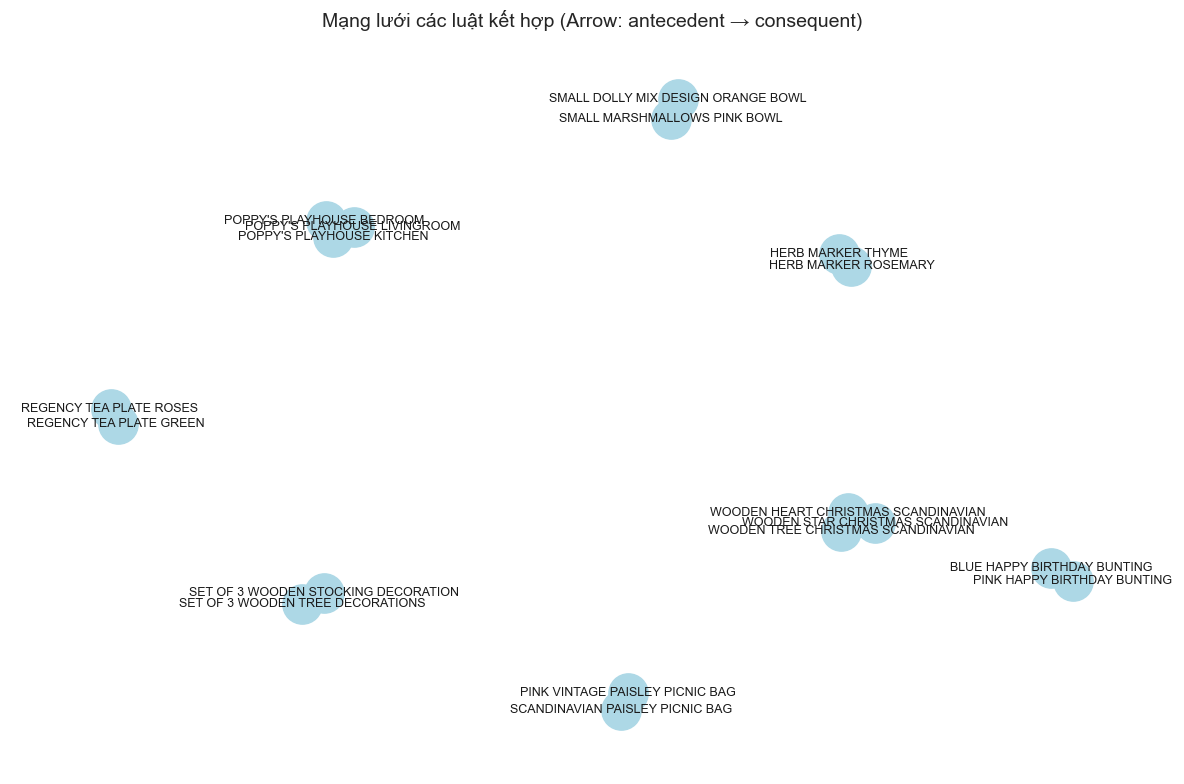

In [28]:
## Network các luật có lift cao
if PLOT_NETWORK and not rules_filtered_ap.empty:
    # Lấy một tập luật nhỏ để vẽ mạng (tránh quá rối)
    visualizer.plot_rules_network(
        rules_df=rules_filtered_ap,
        max_rules=min(TOP_N_RULES, 30),
    )
else:
    if rules_filtered_ap.empty:
        print("Không có luật nào sau khi lọc để vẽ network graph.")
    else:
        print("PLOT_NETWORK = False, bỏ qua network graph.")


In [33]:
## Lưu luật đã lọc ra file CSV

# Lưu luật đã lọc để dùng trong báo cáo / dashboard
miner.save_rules(
    output_path=RULES_OUTPUT_PATH,
    rules_df=rules_filtered_ap,
)

print("Đã lưu luật Apriori đã lọc:")
print(f"- File: {RULES_OUTPUT_PATH}")
print(f"- Số luật: {rules_filtered_ap.shape[0]:,}")


Đã lưu luật vào: data/processed/rules_apriori_filtered.csv
Đã lưu luật Apriori đã lọc:
- File: data/processed/rules_apriori_filtered.csv
- Số luật: 568


In [36]:
import pandas as pd

# Lấy dataframe luật ra
rules = miner.rules

# Nhom sport cao va lift cao
star_rules = rules[ (rules['support'] > 0.02) & (rules['lift'] > 2) ]

# Nhom support thap va lift cao
niche_rules = rules[ (rules['support'] < 0.015) & (rules['lift'] > 5) ]

# Nhom quan he 'ao'
useless_rules = rules[ (rules['confidence'] > 0.6) & (rules['lift'] >= 0.9) & (rules['lift'] <= 1.1) ]


print(" KẾT QUẢ PHÂN LOẠI CHIẾN LƯỢC ")
print(f" NHÓM 1: ----Số lượng: {len(star_rules)}")
if not star_rules.empty:
    print(star_rules[['rule_str', 'support', 'lift']].head(3).to_string())

print(f"\nNHÓM 2-----Số lượng: {len(niche_rules)}")
if not niche_rules.empty:
    print(niche_rules[['rule_str', 'support', 'lift']].head(3).to_string())

print(f"\nNHÓM 3: QUAN HỆ 'ẢO'----Số lượng: {len(useless_rules)}")
if not useless_rules.empty:
    print(useless_rules[['rule_str', 'confidence', 'lift']].head(3).to_string())

 KẾT QUẢ PHÂN LOẠI CHIẾN LƯỢC 
 NHÓM 1: ----Số lượng: 76
                                                                                              rule_str   support       lift
65  PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER  → GREEN REGENCY TEACUP AND SAUCER  0.020485  24.216650
68  GREEN REGENCY TEACUP AND SAUCER → PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER   0.020485  24.216650
69  PINK REGENCY TEACUP AND SAUCER → GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY TEACUP AND SAUCER   0.020485  24.188581

NHÓM 2-----Số lượng: 644
                                                rule_str   support       lift
909             HERB MARKER THYME → HERB MARKER ROSEMARY  0.010153  86.829038
908             HERB MARKER ROSEMARY → HERB MARKER THYME  0.010153  86.829038
586  REGENCY TEA PLATE GREEN  → REGENCY TEA PLATE ROSES   0.011534  52.930211

NHÓM 3: QUAN HỆ 'ẢO'----Số lượng: 0


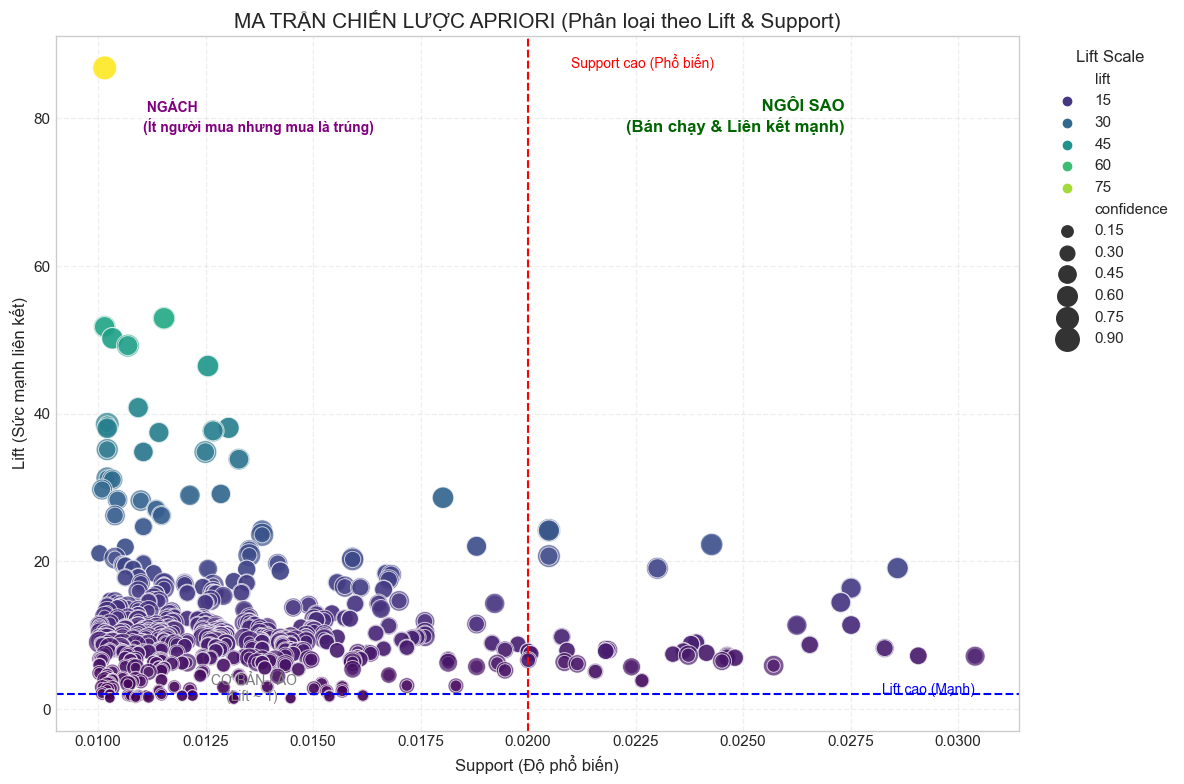

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- BIỂU ĐỒ 1: MA TRẬN CHIẾN LƯỢC (SUPPORT vs LIFT) ---
plt.figure(figsize=(12, 8))

# Vẽ các điểm (Mỗi điểm là 1 luật)
sns.scatterplot(
    x="support", 
    y="lift", 
    size="confidence",  # Kích thước điểm thể hiện độ tin cậy
    hue="lift",         # Màu sắc thể hiện độ mạnh
    data=miner.rules, 
    sizes=(50, 300), 
    palette="viridis", 
    alpha=0.7
)

# --- VẼ CÁC ĐƯỜNG RANH GIỚI CHIẾN LƯỢC (Theo tiêu chí bạn đã chọn) ---
# Đường dọc: Ngưỡng Support (Ví dụ 2% - Phân biệt hàng Phổ biến vs Hàng Ngách)
plt.axvline(x=0.02, color='red', linestyle='--', linewidth=1.5)
plt.text(0.021, miner.rules['lift'].max(), 'Support cao (Phổ biến)', color='red', fontsize=10, ha='left')

# Đường ngang: Ngưỡng Lift (Ví dụ Lift = 2 - Phân biệt Quan hệ Mạnh vs Yếu)
plt.axhline(y=2.0, color='blue', linestyle='--', linewidth=1.5)
plt.text(miner.rules['support'].max(), 2.1, 'Lift cao (Mạnh)', color='blue', fontsize=10, ha='right')

# --- CHÚ THÍCH CÁC VÙNG ---
# Vùng Ngôi Sao (Góc phải trên)
plt.text(miner.rules['support'].max()*0.9, miner.rules['lift'].max()*0.9, 
         ' NGÔI SAO\n(Bán chạy & Liên kết mạnh)', 
         fontsize=12, color='darkgreen', weight='bold', ha='right')

# Vùng Ngách (Góc trái trên)
plt.text(miner.rules['support'].min()*1.1, miner.rules['lift'].max()*0.9, 
         ' NGÁCH\n(Ít người mua nhưng mua là trúng)', 
         fontsize=10, color='purple', weight='bold', ha='left')

# Vùng Ảo/Cơ bản (Phía dưới)
plt.text(miner.rules['support'].mean(), 1.1, 
         ' CƠ BẢN / ẢO\n(Lift ~ 1)', 
         fontsize=10, color='gray', ha='center')

plt.title("MA TRẬN CHIẾN LƯỢC APRIORI (Phân loại theo Lift & Support)", fontsize=15)
plt.xlabel("Support (Độ phổ biến)", fontsize=12)
plt.ylabel("Lift (Sức mạnh liên kết)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Lift Scale')
plt.tight_layout()
plt.show()

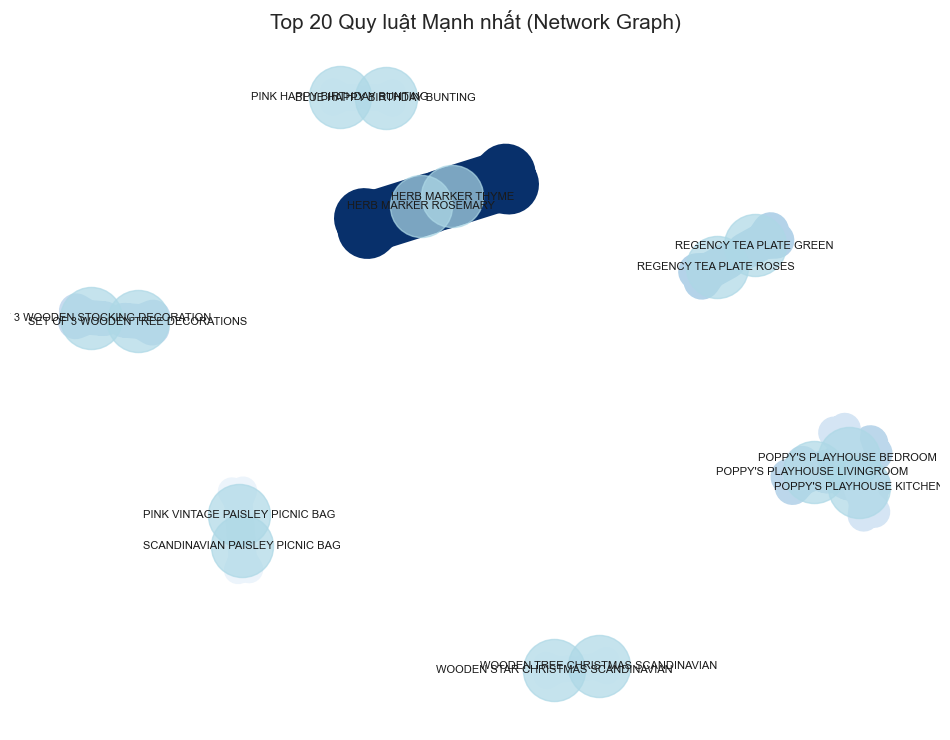

In [42]:
import networkx as nx

# --- BIỂU ĐỒ 2: MẠNG LƯỚI SẢN PHẨM (TOP 20 LUẬT MẠNH NHẤT) ---
plt.figure(figsize=(12, 9))

# 1. Lấy Top 20 luật có Lift cao nhất
top_rules = miner.rules.sort_values('lift', ascending=False).head(20)

# 2. Tạo đồ thị
G = nx.DiGraph()

# 3. Thêm nút và cạnh
for i, row in top_rules.iterrows():
    # Lấy tên sản phẩm (chọn phần tử đầu tiên trong bộ frozenset cho gọn)
    ant = list(row['antecedents'])[0] 
    con = list(row['consequents'])[0]
    
    # Thêm cạnh nối từ A -> B, độ đậm dựa trên Lift
    G.add_edge(ant, con, weight=row['lift'])

# 4. Vẽ đồ thị
pos = nx.spring_layout(G, k=1)  # Bố cục lò xo
edges = G.edges()
weights = [G[u][v]['weight'] for u,v in edges]

# Vẽ nút (Sản phẩm)
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue', alpha=0.7)
# Vẽ nhãn (Tên sản phẩm)
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')
# Vẽ cạnh (Mũi tên) - Độ đậm nhạt tùy theo Lift
nx.draw_networkx_edges(G, pos, width=[w/2 for w in weights], edge_color=weights, 
                       edge_cmap=plt.cm.Blues, arrowstyle='->', arrowsize=20)

plt.title("Top 20 Quy luật Mạnh nhất (Network Graph)", fontsize=15)
plt.axis('off')
plt.show()

## Gợi ý cách đọc & sử dụng các luật kết hợp

Một số hướng khai thác luật kết hợp trong bối cảnh kinh doanh:

- Các luật có **lift cao**:
  - Thể hiện những cặp/bộ sản phẩm gắn bó chặt chẽ hơn nhiều so với ngẫu nhiên.
  - Gợi ý cho: combo sản phẩm, trưng bày trên kệ, chương trình mua kèm.

- Các luật có **confidence cao nhưng support vừa phải**:
  - Thích hợp cho chiến dịch cá nhân hoá: 
  - Khi khách đã mua `antecedent`, xác suất mua `consequent` rất cao.

- Luật có **support cao nhưng lift không quá lớn**:
  - Thể hiện các thói quen mua sắm phổ biến.
  - Giúp hiểu "giỏ hàng trung bình" của khách hàng.

Khi kết hợp với RFM ở Notebook 01, ta có thể:
- Áp dụng luật khác nhau cho nhóm khách hàng VIP / mới / có rủi ro rời bỏ.
- Thiết kế chiến dịch gợi ý sản phẩm theo phân khúc khách hàng cụ thể.
